## DDIM inversion (initalise with MCPL pretrained)

In [1]:
import sys
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser')
from torchvision import transforms
from edit_modules.clip import CLIPTextModel
from edit_modules.embed_manager import EmbeddingManager,Embed_control_manager
from diffusers.models.modeling_utils import load_state_dict
from torchvision import transforms as tfms
from PIL import Image
from transformers import CLIPTokenizer
import torch


from diffusers import StableDiffusionCausalControlNetPipeline, Causal_ControlNetModel, UniPCMultistepScheduler,StableDiffusionPipeline
from causal_modules.ddim_modules import *
size = 256

image_transforms = transforms.Compose(
        [
            transforms.CenterCrop(150),
            transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ]
        )
original_transforms = transforms.Compose(
        [
            transforms.CenterCrop(150),
            transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
        ]
        )

conditioning_image_transforms = transforms.Compose(
            [
                transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
                transforms.ToTensor(),
                #transforms.Normalize([0.5], [0.5]),
            ]
        )
        

In [17]:
'''Load pipeline'''


base_model_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce"
'''causal_discovery'''
# controlnet_path = "../logs_mtx/logs_celeA_complex_all/2025-06-16T16-48-16-textcond_lr5e4_pretrain_accum1_regloss/controlnet-steps-20000.safetensors"
# mcpl_embedding_path = "../logs_mtx/logs_celeA_complex_all/2025-06-16T16-48-16-textcond_lr5e4_pretrain_accum1_regloss/learned_embeds-steps-20000.safetensors"


'''text_cond_contrastive'''
#controlnet_path = "../logs/logs_celeA_complex_all/2025-08-15T11-47-12-controlnet_resume_flipgeneration_text_global_after/controlnet-steps-300000.safetensors"
#mcpl_embedding_path = "../logs/logs_celeA_complex_all/2025-08-15T11-47-12-controlnet_resume_flipgeneration_text_global_after/learned_embeds-steps-300000.safetensors"
# controlnet_path = "../logs/logs_celeA_complex_all/2025-08-15T10-40-48-controlnet_resume_noflipgeneration_text_global_after/controlnet-steps-100000.safetensors"
# mcpl_embedding_path = "../logs/logs_celeA_complex_all/2025-08-15T10-40-48-controlnet_resume_noflipgeneration_text_global_after/learned_embeds-steps-100000.safetensors"
#controlnet_path = "../logs/logs_celeA_complex_all/2025-04-23T17-05-57-controlnet_textcond_constrastivegeneration_text_global_after/controlnet-steps-200000.safetensors"
#mcpl_embedding_path = "../logs/logs_celeA_complex_all/2025-04-23T17-05-57-controlnet_textcond_constrastivegeneration_text_global_after/learned_embeds-steps-200000.safetensors"
#controlnet_path = "../logs/logs_celeA_complex_all/2025-08-13T22-31-05-controlnet_textcond_constrastivegeneration_text_global_after/controlnet-steps-400000.safetensors"
#mcpl_embedding_path = "../logs/logs_celeA_complex_all/2025-08-13T22-31-05-controlnet_textcond_constrastivegeneration_text_global_after/learned_embeds-steps-400000.safetensors"
# controlnet_path = "../logs/logs_celeA_complex_all/2025-04-17T20-43-28-controlnet_textcond_constrastivegeneration_text_global_after/controlnet-steps-100000.safetensors"
# mcpl_embedding_path = "../logs/logs_celeA_complex_all/2025-04-17T20-43-28-controlnet_textcond_constrastivegeneration_text_global_after/learned_embeds-steps-100000.safetensors"
'''text_cond'''
#controlnet_path = "../logs/logs_celeA_complex_all/2025-04-21T08-46-52-controlnet_textcond_nocontrastgeneration_text_global_after/controlnet-steps-100000.safetensors"
#mcpl_embedding_path = "../logs/logs_celeA_complex_all/2025-04-21T08-46-52-controlnet_textcond_nocontrastgeneration_text_global_after/learned_embeds-steps-100000.safetensors"
'''image_cond'''
# controlnet_path = "../logs/logs_celeA_complex_all/2025-05-20T14-44-34-controlnet_nomcplgeneration_image/controlnet-steps-100000.safetensors"
# mcpl_embedding_path = "../logs/logs_celeA_complex_all/2025-05-20T14-44-34-controlnet_nomcplgeneration_image/learned_embeds-steps-100000.safetensors"
#controlnet_path = "../logs/logs_pendulum_all/2025-04-02T10-49-18-controlnet_textcondgeneration_text_global_after/controlnet-steps-30000.safetensors"
#mcpl_embedding_path = None
#causalnet_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs/logs_celeA_complex_all/2025-04-23T21-11-19-causalnet_pretrain/best_model.pt'

'''different prompt string'''
controlnet_path = "../logs/logs_celeA_complex_all/2025-10-06T16-21-07-controlnet_textcond_constrastive_shortstringgeneration_text_global_after/controlnet-steps-100000.safetensors"
mcpl_embedding_path = "../logs/logs_celeA_complex_all/2025-10-06T16-21-07-controlnet_textcond_constrastive_shortstringgeneration_text_global_after/learned_embeds-steps-100000.safetensors"#


causalnet_path = None
device = torch.device("cuda")
controlnet = Causal_ControlNetModel.from_pretrained(controlnet_path,torch_dtype=torch.float32)
print(controlnet.task_cond)
if causalnet_path is not None:
    print('load pretrained causalnet weights')
    controlnet.controlnet_cond_embedding.load_state_dict(torch.load(causalnet_path,weights_only=True))

A_matrix = torch.tensor([[0, 0, 1,1], [0, 0, 1,1], [0, 0, 0,0], [0, 0, 0,0]],dtype=torch.float32).to(device)
controlnet.controlnet_cond_embedding.update_mask(A_matrix)
controlnet.eval()
print('training_mode', controlnet.task_cond)
# Load mcpl embedding
#prompt = "a people photo of young and female and beard and bald"
#prompt = 'a human of @ and * and & and !'
prompt = 'an image of @ * & !'
#prompt = '@ * & !'
presudo_words= '@,*,&,!'
#presudo_words = 'young,female,beard,bald'
presudo_list = presudo_words.split(',')
tokenizer = CLIPTokenizer.from_pretrained(base_model_path,subfolder="tokenizer")
presudo_token_ids = tokenizer.encode(' '.join(presudo_list), add_special_tokens=False)
embed_control_manager_bool = True
if 'image' in controlnet.task_cond:
    embed_control_manager_bool = False
text_encoder = load_mcpl_embeddings(base_model_path,tokenizer,mcpl_embedding_path,presudo_token_ids,embed_control=embed_control_manager_bool)

pipe = StableDiffusionCausalControlNetPipeline.from_pretrained(
    base_model_path, controlnet=controlnet,text_encoder=text_encoder ,torch_dtype=torch.float32
)
pipe.scheduler = DDIMScheduler.from_config(
    pipe.scheduler.config
)
pipe.safety_checker = None
pipe.requires_safety_checker = False
#pipe.load_mcpl_inversion(mcpl_embedding_path)


# memory optimization.
pipe = pipe.to(device)

Skipping initialization on meta device.
Skipping initialization on meta device.
generation_text_global_after
training_mode generation_text_global_after
Loaded textual inversion embedding for 256.
Loaded textual inversion embedding for 261.
Loaded textual inversion embedding for 265.
Loaded textual inversion embedding for 287.
load embedding control


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76

In [18]:
'''from training set'''
import random
import pandas as pd
from torchvision.datasets import CelebA
def dataset_load_path(data_root,dataset,split='train'):
    data_dir = data_root
    data = CelebA(root=data_dir, split=split, transform=None, download=False)
    num_images = len(data)
    if 'simple' in dataset:
        selected_item = ['Smiling','Eyeglasses']
    
    elif 'complex' in dataset:
        selected_item = ['Young','Male','No_Beard','Bald']
    else:
        AssertionError('no such {} dataset'.format(dataset))
    attribute_ids = [data.attr_names.index(attr) for attr in selected_item]
    metrics = {attr: torch.as_tensor(data.attr[:, attr_id], dtype=torch.float32) for attr, attr_id in zip(selected_item, attribute_ids)}

    attrs = torch.cat([metrics[attr].unsqueeze(1)
                            for attr in selected_item], dim=1)
    imglabel= attrs
    possible_values = {attr: torch.unique(values, dim=0) for attr, values in metrics.items()}
    
    img_id = random.randint(0,num_images)
    return data,imglabel,num_images

#img_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/causal_data/pendulum/test/a_-1_128_4_12.png'
data,imglabel,num_images = dataset_load_path(data_root='/home/jovyan/fcvm-data-volume/kzzr229/workspace/counterfactual-benchmark/datasets/',dataset=controlnet.dataset,split='test')

In [19]:
# paper image id (190,34，2,31)
# ablation (test2,test190,valid23,test25)
img_id = random.randint(0,num_images)
img_id=25
img,label = data[img_id][0],imglabel[img_id].unsqueeze(0)
label

tensor([[1., 0., 1., 0.]])

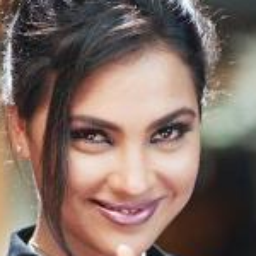

In [20]:

image = img
if not image.mode == "RGB":
    image = image.convert("RGB")

original_img = image.copy()
original_img = original_transforms(original_img)
condition_image = image.copy()
image = image_transforms(image)
original_img

# Plot Attn Maps

In [21]:
import os
prompts = [prompt]
out_base = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/outputs/attention_maps/'
exp_name = 'textcond_celeba_{}'.format(img_id)
if not os.path.exists(out_base):
    os.mkdir(out_base) 
out_path_base = os.path.join(out_base, exp_name)
if not os.path.exists(out_path_base):
    os.mkdir(out_path_base) 
out_path_prompt = os.path.join(out_path_base, prompts[0])
if not os.path.exists(out_path_prompt):
    os.mkdir(out_path_prompt)
out_dir = out_path_prompt
out_name = 'causalnet'+'.png'

ax shape: (1, 7)


100%|██████████| 49/49 [00:02<00:00, 19.89it/s]


  0%|          | 0/50 [00:00<?, ?it/s]

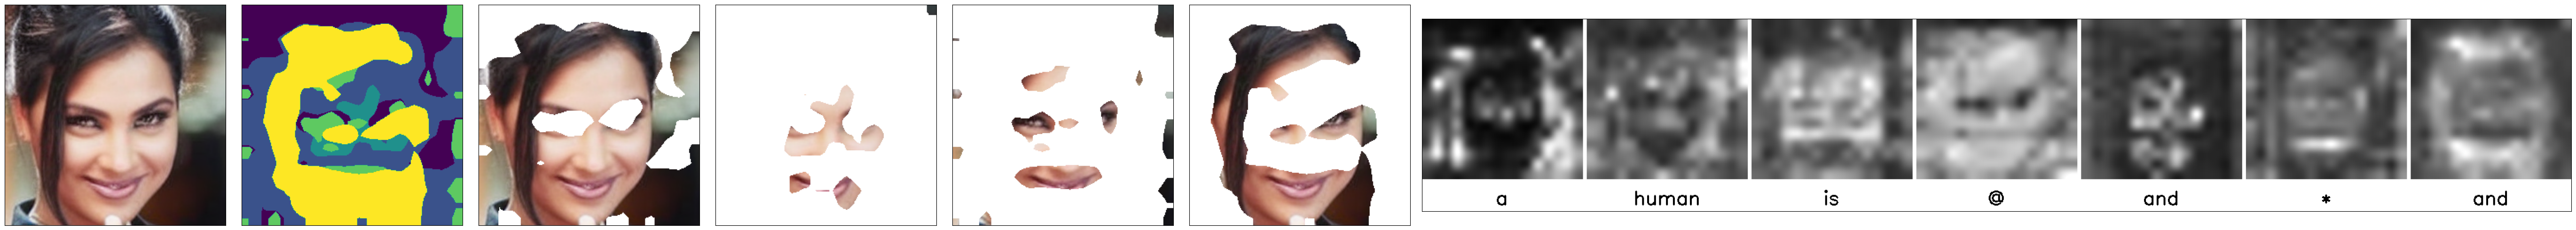

<Figure size 640x480 with 0 Axes>

In [22]:
import sys
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser')
from scripts.show_attn_maps import ptp_tools,ptp_utils
import importlib
importlib.reload(ptp_tools)
importlib.reload(ptp_utils)
attn_threshold = 0.5

# pipe = StableDiffusionCausalControlNetPipeline.from_pretrained(
#     base_model_path, controlnet=controlnet,text_encoder=text_encoder ,torch_dtype=torch.float32
# )
# pipe.scheduler = DDIMScheduler.from_config(
#     pipe.scheduler.config
# )
# pipe.safety_checker = None
# pipe.requires_safety_checker = False
# #pipe.load_mcpl_inversion(mcpl_embedding_path)
generator = torch.manual_seed(0)

# # memory optimization.
# #pipe.enable_model_cpu_offload()
# pipe = pipe.to(device)

overlapped_mask,attn_img = ptp_tools.plot_img_attn_mask_textcontrol(pipe, prompts,presudo_words,condition_image, \
        device, out_dir, out_name, latent=image.unsqueeze(0),res=16,label=label, \
        GUIDANCE_SCALE=1.0,attn_threshold=attn_threshold, only_sampling=False,show_text=True,save_masks=False,class_select=False,\
        intervention_indx=None,intervention_values=None,from_where=['down','up'],mask_concepts=True, g_gpu=generator,num_steps=50,img_size=size,exp_names=[exp_name],dataset='celeba')

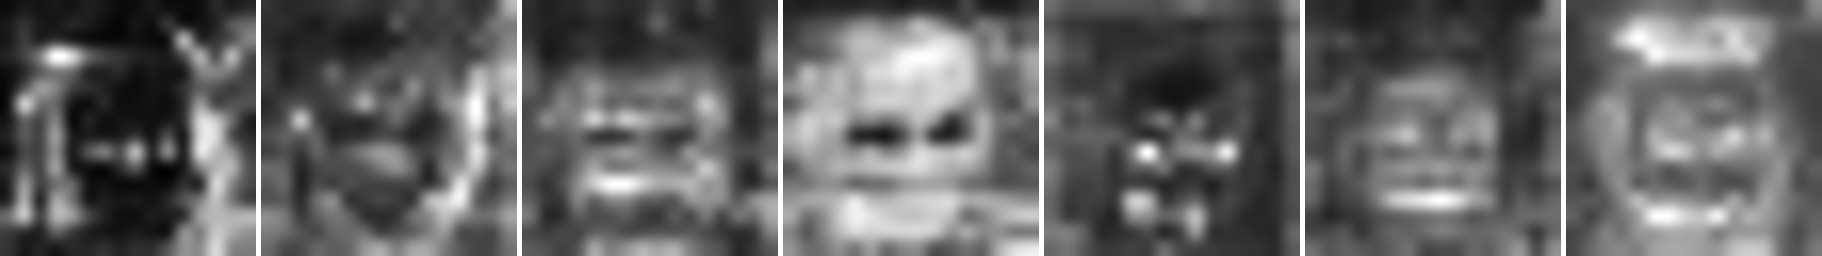

In [10]:
attn_img

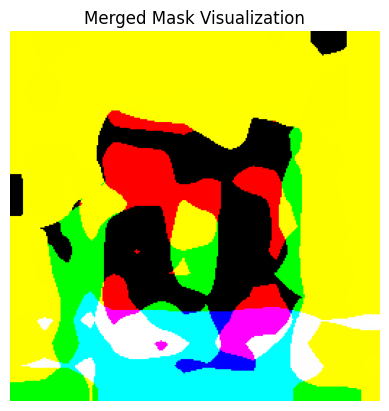

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Example: your mask tensor
# Shape: (256, 256, 4)
mask_list = overlapped_mask

# Define colors for each mask (R, G, B)
colors = [
    [255, 0, 0],    # red
    [0, 255, 0],    # green
    [0, 0, 255],    # blue
    [255, 255, 0],  # yellow
]

# Initialize a blank RGB image
composite = torch.zeros(256, 256, 3, dtype=torch.uint8)

# Blend each mask into the composite using its color
for i in range(4):
    for c in range(3):
        composite[:, :, c] += (mask_list[:, :, i] * colors[i][c]).to(torch.uint8)

# Clamp to valid [0, 255] range (in case of overlapping)
composite = torch.clamp(composite, 0, 255)

# Convert to NumPy for visualization
composite_np = composite.numpy()

# Show image
plt.imshow(composite_np)
plt.axis('off')
plt.title("Merged Mask Visualization")
plt.show()
